# Estudio comparativo de algoritmos Softmax en el problema k-armed bandits
*Description:* El experimento compara el rendimiento de algoritmos softmax en un problema de k-armed bandit.
Se generan distintas gráficas para visualizar el rendimiento de cada algoritmo, incluyendo la recompensa promedio a lo largo del tiempo y la tasa de selección de la mejor acción.

    Authors: Ginés Carrillo Ibáñez, Yago Ibarrola Lapeña, Aarón Palomar Peña
    Emails: gines.carrilloi@um.es, yago.ibarrolal@um.es, aaron.p.p@um.es
    Date: 2026/02/06

## Preparación del entorno


In [2]:
#!git clone https://github.com/YagoIbarrola/EML_Carrillo_Ibarrola_Palomar.git
#!cd k_brazos/

In [3]:
#@title Importamos todas las clases y funciones

import sys

# Añadir los directorio fuentes al path de Python
sys.path.append('/content/k_brazos/src')


# Verificar que se han añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, EpsilonGreedy, EpsilonDecaimiento, UCB1, UCB2, Softmax
from arms import ArmNormal, ArmBernoulli, ArmBinomial, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret
from utils import run_experiment


['c:\\Users\\aaron\\miniconda3\\envs\\EML\\python310.zip', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\DLLs', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\lib', 'c:\\Users\\aaron\\miniconda3\\envs\\EML', '', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\lib\\site-packages', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\lib\\site-packages\\win32', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\lib\\site-packages\\win32\\lib', 'c:\\Users\\aaron\\miniconda3\\envs\\EML\\lib\\site-packages\\Pythonwin', '/content/k_brazos/src']


## Ejecución del experimento

Ejecutaremos tres versiones del algoritmo softmax, cada una con un valor diferente de la temperatura ($\tau$). Esto nos permitirá observar cómo la temperatura afecta la exploración y explotación en el problema de k-armed bandits.

Teóricamente, una temperatura alta ($\tau$) debería fomentar la exploración, mientras que una temperatura baja debería favorecer la explotación. Vamos a ver cómo se comportan estos algoritmos en la práctica.

Además, realizaremos el experimento para tres tipos de brazos: normal, Bernoulli y binomial. Esto nos permitirá comparar el rendimiento de los algoritmos softmax en diferentes contextos y entender mejor su comportamiento.

In [4]:

# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 3000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

### Experimento 1: Distribución normal

Para el primer experimento utilizamos 10 brazos con distribución normal, cada uno con una media aleatoria entre 1 y 10, y una desviación estándar de 1. Ejecutamos los algoritmos softmax con temperaturas $\tau = 0.1$, $\tau = 1.0$ y $tau = 10.0$ durante 3000 pasos y repetimos el experimento 500 veces para obtener resultados estadísticamente significativos.

In [5]:

# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, temperature=0.1), Softmax(k=k, temperature=1), Softmax(k=k, temperature=5)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56



Vemos que los brazos tienen las siguientes medias: [1.52, 2.4, 1.19, 4.37, 6.39, 7.59, 8.8, 9.56, 6.41, 7.37]. El brazo óptimo es el número 8 (índice 7) con una media de recompensa de 9.56.

A continuación, se muestran las gráficas de recompensa promedio a lo largo del tiempo.

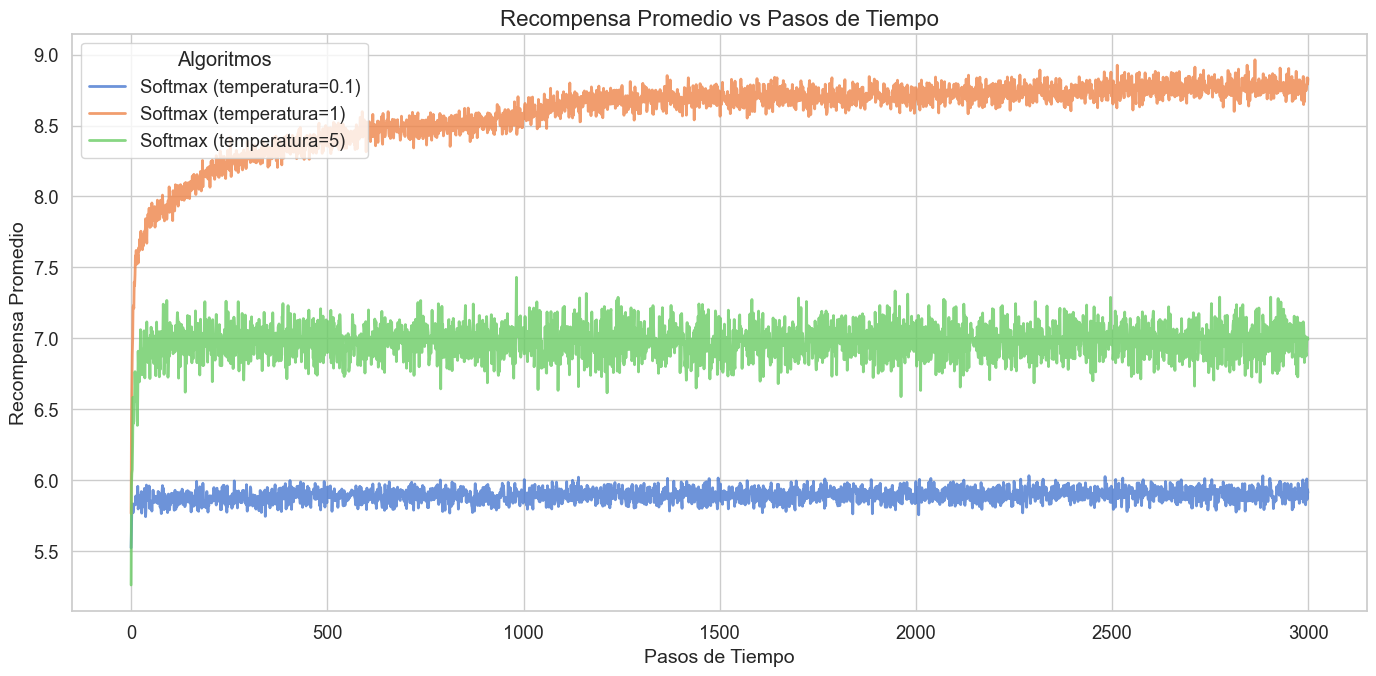

In [6]:
plot_average_rewards(steps, rewards, algorithms)

Esta gráfica muestra la recompensa promedio obtenida por cada algoritmo a lo largo de los 3000 pasos, para cada una de las temperaturas utilizadas. En el eje x se representan los pasos de tiempo, mientras que en el eje y se muestra la recompensa promedio. 

- La línea **azul** corresponde al algoritmo softmax con $\tau = 0.1$, que es el más explotador de los tres. Esto ocurre porque con una temperatura baja, el algoritmo tiende a seleccionar la acción con la mayor recompensa estimada, lo que puede llevar a una rápida convergencia pero también a quedar atrapado en un óptimo local, que es lo que parece estar sucediendo aquí, ya que la recompensa promedio se estabiliza en un valor muy inferior al óptimo. Es un caso similar a un algoritmo greedy puro, que siempre selecciona la acción con la mayor recompensa estimada.
  
- La línea **naranja** corresponde al algoritmo softmax con $\tau = 1.0$, que es un equilibrio entre exploración y explotación. Este algoritmo muestra una recompensa promedio que se acerca al óptimo, aunque no lo alcanza completamente. A medida que pasa el tiempo, la probabilidad del mejor brazo es lo suficientemente alta como para ser seleccionado la mayoría de las veces, pero no tanto como para anular la exploración por completo.
  
- La línea **verde** corresponde al algoritmo softmax con $\tau = 0.1$, que es el más explorador de los tres. Con una temperatura alta, las diferencias entre los valores de recompensa estimados se suavizan demasiado. Aunque el algoritmo sepa que un brazo es mejor (tiene mayor Q), al dividir por 5.0, los exponentes $e^{Q/τ}$ se parecen mucho entre sí.

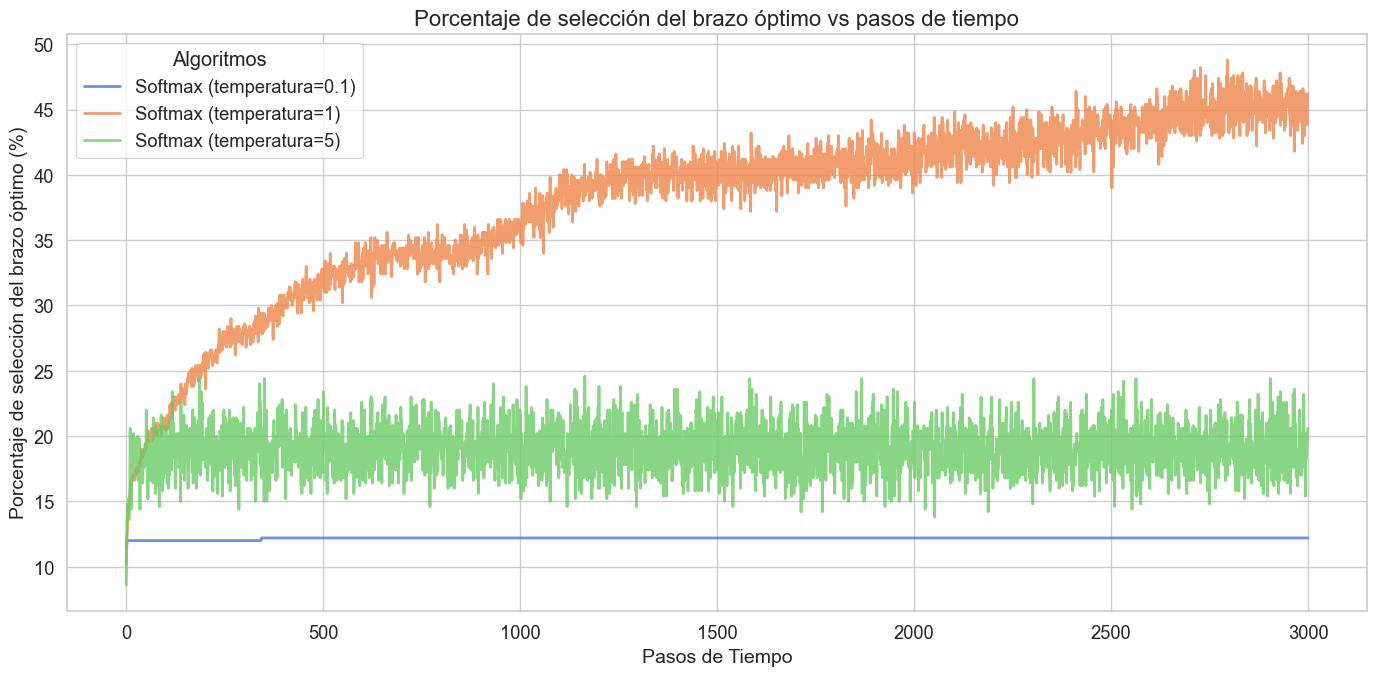

In [7]:
plot_optimal_selections(steps, optimal_selections, algorithms)

En esta gráfica, titulada 'Porcentaje de selección del brazo óptimo vs pasos de tiempo', se muestra el porcentaje de veces que cada algoritmo selecciona el brazo óptimo a lo largo de los 3000 pasos. En el eje x se representan los pasos de tiempo, mientras que en el eje y se muestra el porcentaje de selección del brazo óptimo.

Los resultados son muy similares a los observados en la gráfica de recompensa promedio.
- El algoritmo con $\tau = 0.1$ (línea azul) tiene un porcentaje de selección del brazo óptimo que se estabiliza en un valor muy bajo, lo que indica que se queda atrapado en un óptimo local. 
  
- El algoritmo con $\tau = 1.0$ (línea naranja) muestra una tendencia a aumentar el porcentaje de selección del brazo óptimo a lo largo del tiempo, si bien esta tendencia es muy lenta en comparación con otros algoritmos ya vistos como epsilon-greedy, que en 1000 pasos se estabilizaban por encima del 85% de selección del brazo óptimo. 

- Por último, el algoritmo con $\tau = 0.1$ (línea verde) tiene un porcentaje de selección del brazo óptimo estabilizado alrededor del 20%, lo cual está bastante cerca de ser aleatorio (10% para 10 brazos), lo que confirma que con una temperatura tan alta, el algoritmo no es capaz de distinguir entre los brazos y selecciona casi al azar.

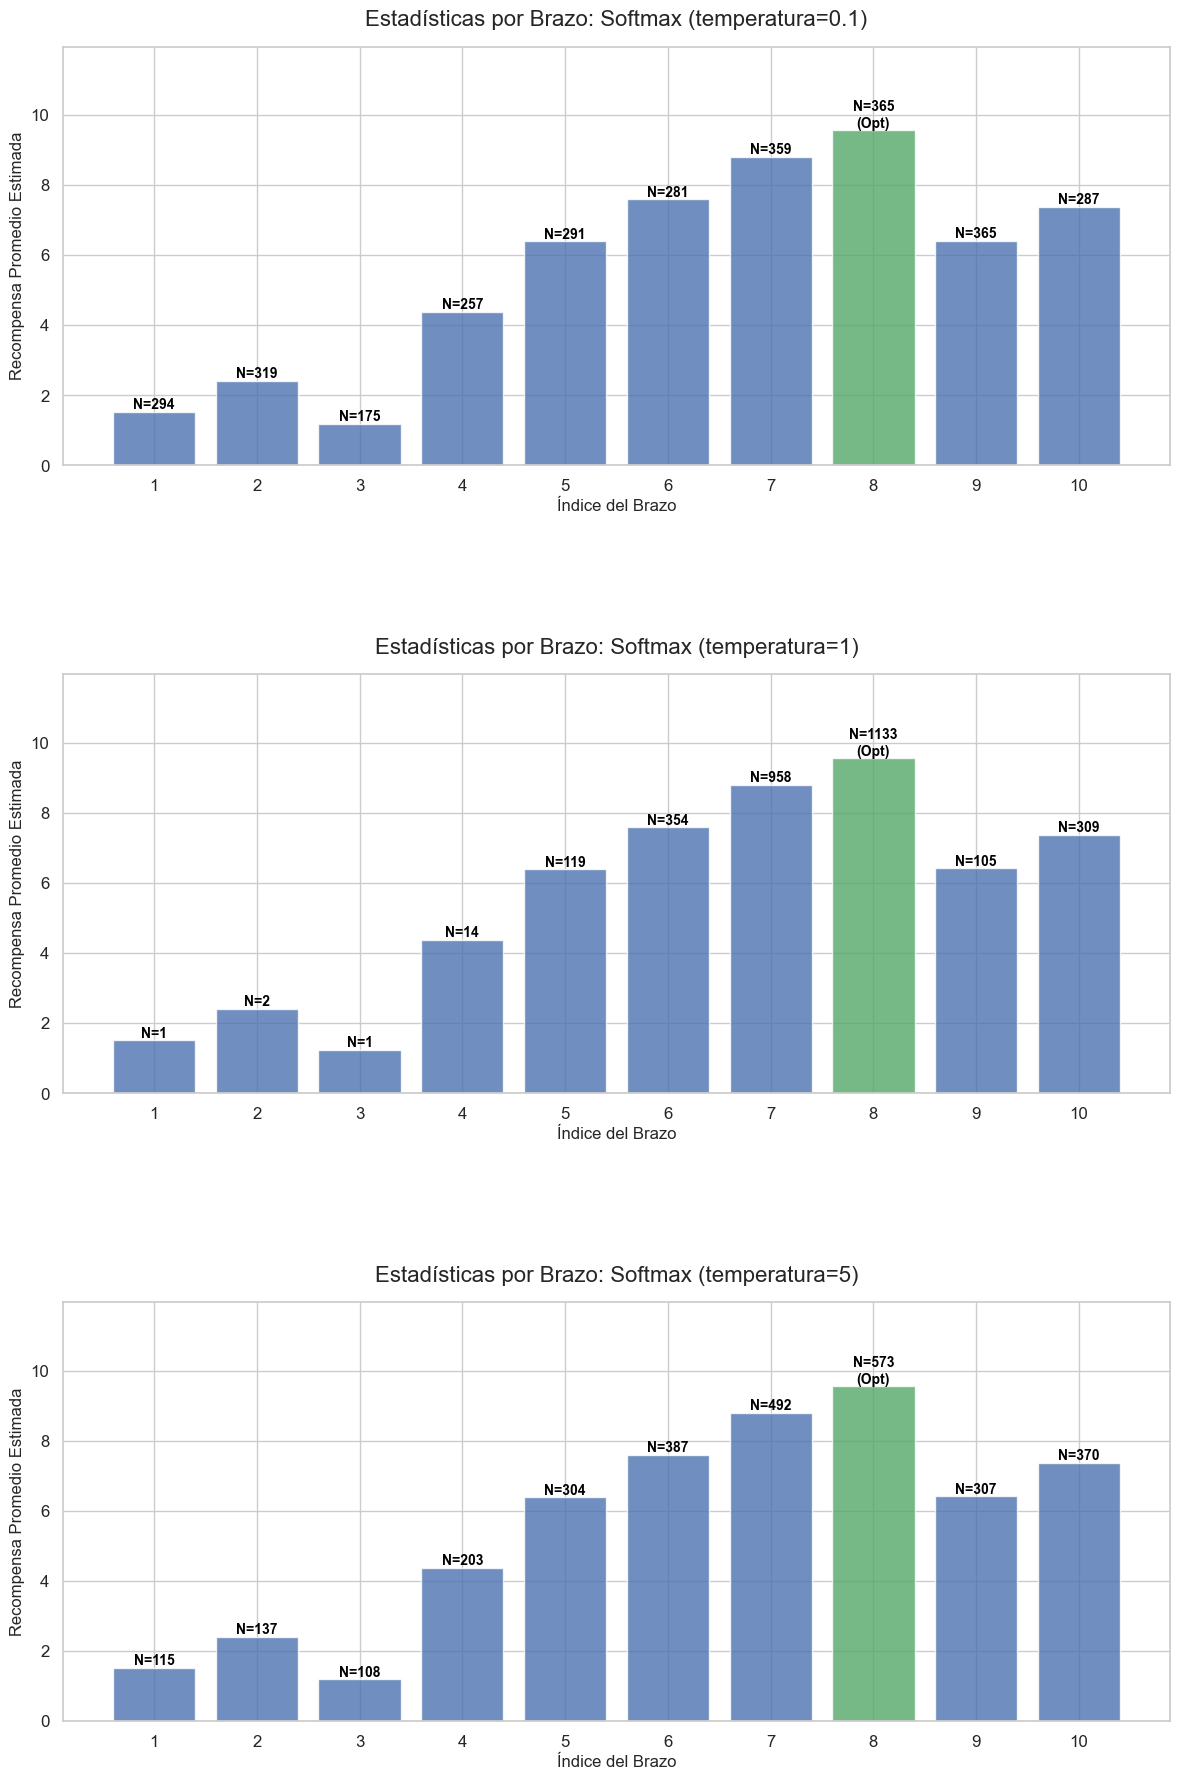

In [8]:
plot_arm_statistics(arms_stats, algorithms, optimal_arm)

En estos cuatro histogramas comprobamos lo que hemos visto en las gráficas anteriores. 

El algoritmo con $\tau = 0.1$ a primera vista puede parecer que está realizando exploración, pues todos los brazos son seleccionados un número similar de veces. Sin embargo, lo que ocurre realmente es que el algoritmo se suele quedar atrapado al inicio del experimento. Veamos un ejemplo concreto: 

- Inicialmente, todos los brazos tienen una recompensa estimada de 0. En el primer paso, el algoritmo selecciona un brazo al azar (por ejemplo, el brazo 3) y obtiene una recompensa de 1.5. Entonces para la siguiente selección, el algoritmo asigna las siguientes probabilidades a cada brazo: 
  - Brazo 1: $P(1) = \frac{e^{0/0.1}}{e^{0/0.1} + e^{0/0.1} + e^{1.5/0.1} + ...} \approx 0$
  - Brazo 2: $P(2) = \frac{e^{0/0.1}}{e^{0/0.1} + e^{0/0.1} + e^{1.5/0.1} + ...} \approx 0$
  - Brazo 3: $P(3) = \frac{e^{1.5/0.1}}{e^{0/0.1} + e^{0/0.1} + e^{1.5/0.1} + ...} \approx 1$
  - Brazo 4: $P(4) = \frac{e^{0/0.1}}{e^{0/0.1} + e^{0/0.1} + e^{1.5/0.1} + ...} \approx 0$
  - ...
- Por tanto, el algoritmo se quedará atrapado la mayoría de las veces en el brazo 3, que no es el óptimo, y no explorará lo suficiente para descubrir que el brazo 8 es el mejor.

En la siguiente celda se pueden ver las probabilidades concretas de este ejemplo:

In [9]:
# Vemos las recompensas asignadas a cada brazo
r = 1.5
print(f"Recompensa asignada al brazo 3: {r}")
array_q = np.array([0, 0, r, 0, 0, 0, 0, 0, 0, 0])
tau = 0.1
probabilities = np.exp(array_q / tau) / np.sum(np.exp(array_q / tau))
print(f"Probabilidades de selección para cada brazo: {probabilities}")

Recompensa asignada al brazo 3: 1.5
Probabilidades de selección para cada brazo: [3.05901478e-07 3.05901478e-07 9.99997247e-01 3.05901478e-07
 3.05901478e-07 3.05901478e-07 3.05901478e-07 3.05901478e-07
 3.05901478e-07 3.05901478e-07]


El algoritmo con $\tau = 0.1$ sí que muestra una mayor capacidad de exploración, lo que le permite descubrir el brazo óptimo a lo largo del tiempo. Sin embargo, la recompensa promedio y el porcentaje de selección del brazo óptimo no alcanzan valores tan altos como en otros algoritmos vistos anteriormente, lo que sugiere que el equilibrio entre exploración y explotación no es tan efectivo en este caso. 

Tanto el brazo 8 como el 7 son los más seleccionados, pero el algoritmo no es capaz de distinguir que el 8 es el mejor, ya que ambos tienen un número similar de selecciones. Esto se debe a que con $\tau = 1.0$, las diferencias entre los valores de recompensa estimados se suavizan, lo que hace que el algoritmo no favorezca suficientemente al brazo óptimo.

Veamos el ejemplo concreto anterior con $\tau = 0.1$:

- Brazo 1: $P(1) = \frac{e^{0/1.0}}{e^{0/1.0} + e^{0/1.0} + e^{1.5/1.0} + ...} \approx 0.07$
- Brazo 2: $P(2) = \frac{e^{0/1.0}}{e^{0/1.0} + e^{0/1.0} + e^{1.5/1.0} + ...} \approx 0.07$
- Brazo 3: $P(3) = \frac{e^{1.5/1.0}}{e^{0/1.0} + e^{0/1.0} + e^{1.5/1.0} + ...} \approx 0.33$
- Brazo 4: $P(4) = \frac{e^{0/1.0}}{e^{0/1.0} + e^{0/1.0} + e^{1.5/1.0} + ...} \approx 0.07$
- ...

En este caso, aunque el brazo 3 tiene una probabilidad de selección más alta que los demás, el algoritmo todavía tiene una probabilidad significativa de seleccionar otros brazos (aproximadamente 67%), lo que le permite eventualmente descubrir el brazo óptimo.

In [10]:
# Vemos las recompensas asignadas a cada brazo
r = 1.5
print(f"Recompensa asignada al brazo 3: {r}")
array_q = np.array([0, 0, r, 0, 0, 0, 0, 0, 0, 0])
tau = 0.1
probabilities = np.exp(array_q / tau) / np.sum(np.exp(array_q / tau))
print(f"Probabilidades de selección para cada brazo: {probabilities}")

Recompensa asignada al brazo 3: 1.5
Probabilidades de selección para cada brazo: [3.05901478e-07 3.05901478e-07 9.99997247e-01 3.05901478e-07
 3.05901478e-07 3.05901478e-07 3.05901478e-07 3.05901478e-07
 3.05901478e-07 3.05901478e-07]


Finalmente, el algoritmo con $\tau = 0.1$ muestra un comportamiento más explorador, pues las probabilidades de selección de los brazos son más uniformes que con $\tau = 1.0$. Veamos el ejemplo concreto:
- Brazo 1: $P(1) = \frac{e^{0/5.0}}{e^{0/5.0} + e^{0/5.0} + e^{1.5/5.0} + ...} \approx 0.09$
- Brazo 2: $P(2) = \frac{e^{0/5.0}}{e^{0/5.0} + e^{0/5.0} + e^{1.5/5.0} + ...} \approx 0.09$
- Brazo 3: $P(3) = \frac{e^{1.5/5.0}}{e^{0/5.0} + e^{0/5.0} + e^{1.5/5.0} + ...} \approx 0.13$
- Brazo 4: $P(4) = \frac{e^{0/5.0}}{e^{0/5.0} + e^{0/5.0} + e^{1.5/5.0} + ...} \approx 0.09$
- ...

En este caso, todos los brazos tienen prácticamente la misma probabilidad de selección, lo que confirma que la decisión de qué brazo a elegir va a ser tomada prácticamente al azar. 

In [11]:
# Vemos las recompensas asignadas a cada brazo
r = 1.5
print(f"Recompensa asignada al brazo 3: {r}")
array_q = np.array([0, 0, r, 0, 0, 0, 0, 0, 0, 0])
tau = 0.1
probabilities = np.exp(array_q / tau) / np.sum(np.exp(array_q / tau))
print(f"Probabilidades de selección para cada brazo: {probabilities}")

Recompensa asignada al brazo 3: 1.5
Probabilidades de selección para cada brazo: [3.05901478e-07 3.05901478e-07 9.99997247e-01 3.05901478e-07
 3.05901478e-07 3.05901478e-07 3.05901478e-07 3.05901478e-07
 3.05901478e-07 3.05901478e-07]


También parece interesante ver qué porcentajes se obtendrían para el caso de establecer la recompensa promedio de cada brazo a su media real, es decir, para el brazo 8 se asignaría una recompensa de 9.56, para el brazo 7 una recompensa de 8.8, etc.

De esta manera podremos ver qué capacidad de selección tiene realmente el algoritmo.

In [12]:
# Vemos las recompensas asignadas a cada brazo
r = 1.5
print(f"Recompensa asignada al brazo 3: {r}")
array_q = np.array(bandit.get_expected_rewards())  # Asignar a cada brazo su recompensa promedio real
tau = 0.1
probabilities = np.exp(array_q / tau) / np.sum(np.exp(array_q / tau))
print(f"Probabilidades de selección para cada brazo: {probabilities}")

Recompensa asignada al brazo 3: 1.5
Probabilidades de selección para cada brazo: [1.20922290e-35 8.02227981e-32 4.45999708e-37 2.88336152e-23
 1.70862845e-14 2.78087467e-09 5.00201106e-04 9.99499796e-01
 2.08692350e-14 3.08129696e-10]


Vemos que el brazo 8 tiene una probabilidad de selección del 19%, que se corresponde con el porcentaje que alcanza entre todas las simulaciones.

Por último, vamos a ver la gráfica de evolución del regret acumulado a lo largo del tiempo para cada algoritmo:

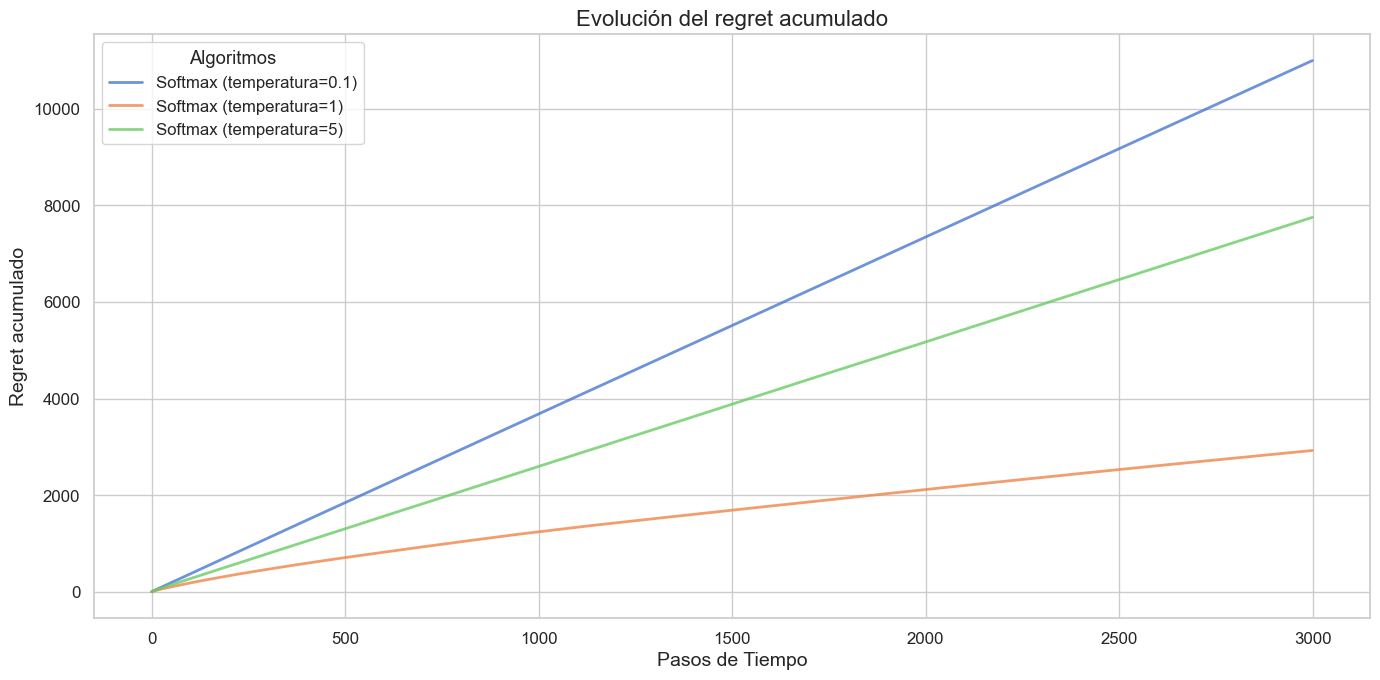

In [13]:
plot_regret(steps, regret_accumulated, algorithms)

 En esta gráfica, titulada 'Regret acumulado vs pasos de tiempo', se muestra el regret acumulado a lo largo de los 3000 pasos para cada uno de los algoritmos softmax con diferentes temperaturas. En el eje x se representan los pasos de tiempo, mientras que en el eje y se muestra el regret acumulado.

 El comportamiento es muy similar al resto de gráficas. La evolución del regret acumulado es lineal para todos los valores de tau, pero con diferentes pendientes.

### Experimento 2: Distribución Bernoulli
A continuación, realizamos el mismo experimento pero con brazos de distribución Bernoulli, cada uno con una probabilidad de éxito aleatoria entre 0.1 y 1. Realizamos un escalado de las recompensas multiplicando por 10 para que los resultados sean más comparables con el experimento anterior y poder usar las mismas temperaturas ($\tau = 0.1$, $\tau = 1.0$ y $\tau = 0.1$). 

In [14]:

np.random.seed(seed)  # Fijar la semilla para reproducibilidad

# Creación del bandit
bandit = Bandit(arms=ArmBernoulli.generate_arms(k, scale= 10.0)) # Generar un bandido con k brazos de distribución Bernoulli
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos softmax con diferentes valores de temperatura.
algorithms = [Softmax(k=k, temperature=0.1), Softmax(k=k, temperature=1), Softmax(k=k, temperature=5)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBernoulli(p=0.44), ArmBernoulli(p=0.96), ArmBernoulli(p=0.76), ArmBernoulli(p=0.24), ArmBernoulli(p=0.64), ArmBernoulli(p=0.15), ArmBernoulli(p=0.88), ArmBernoulli(p=0.64), ArmBernoulli(p=0.74), ArmBernoulli(p=0.12)
Optimal arm: 2 with expected reward=9.556000000000001


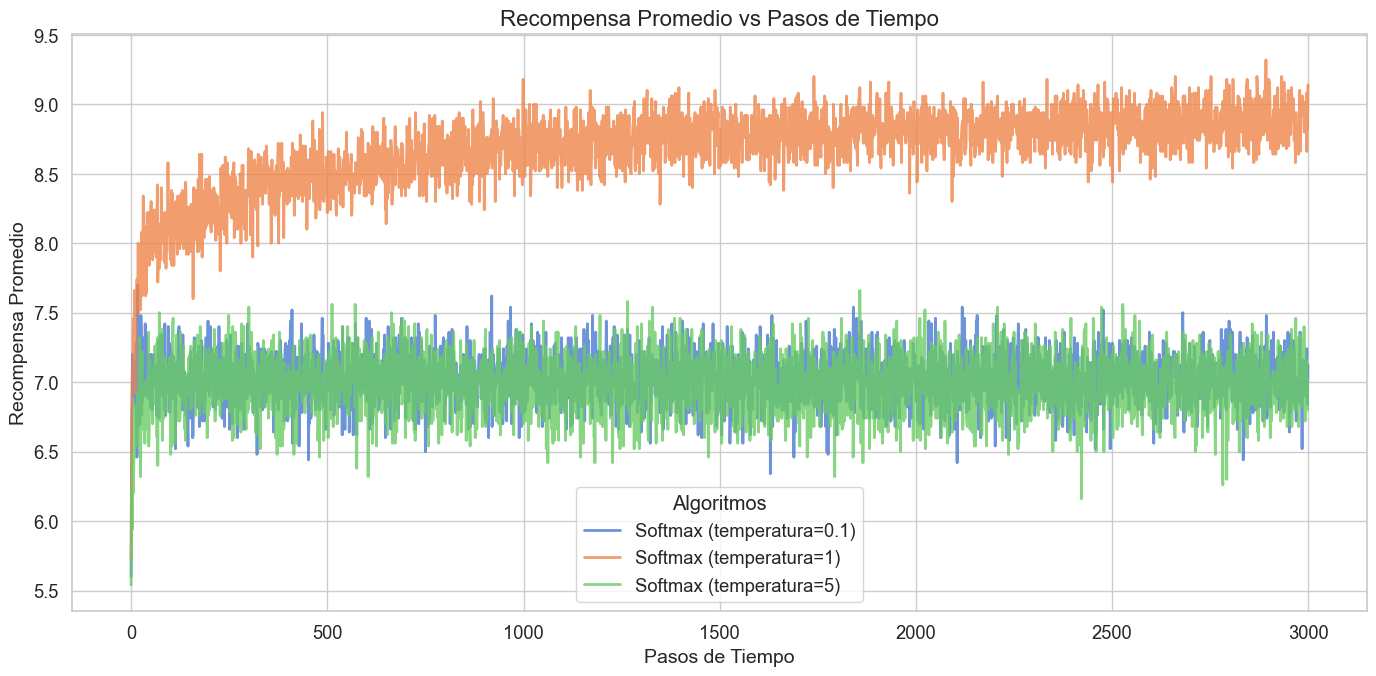

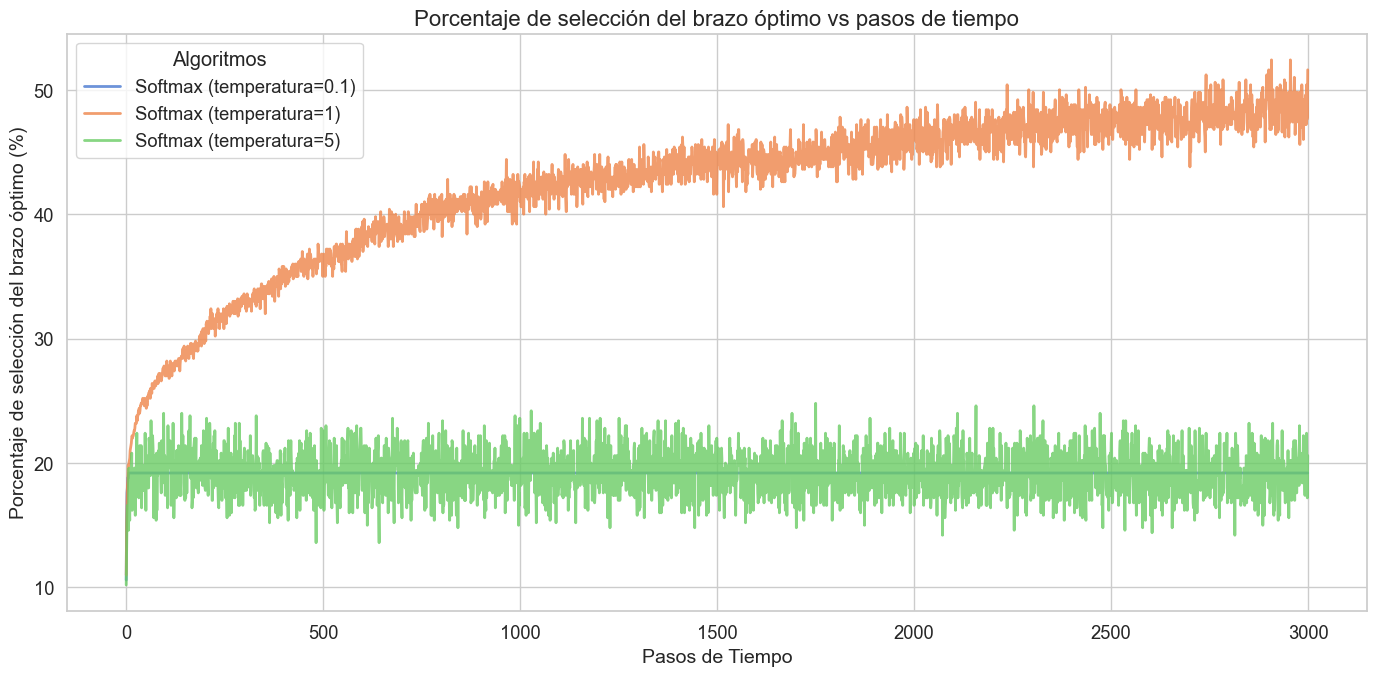

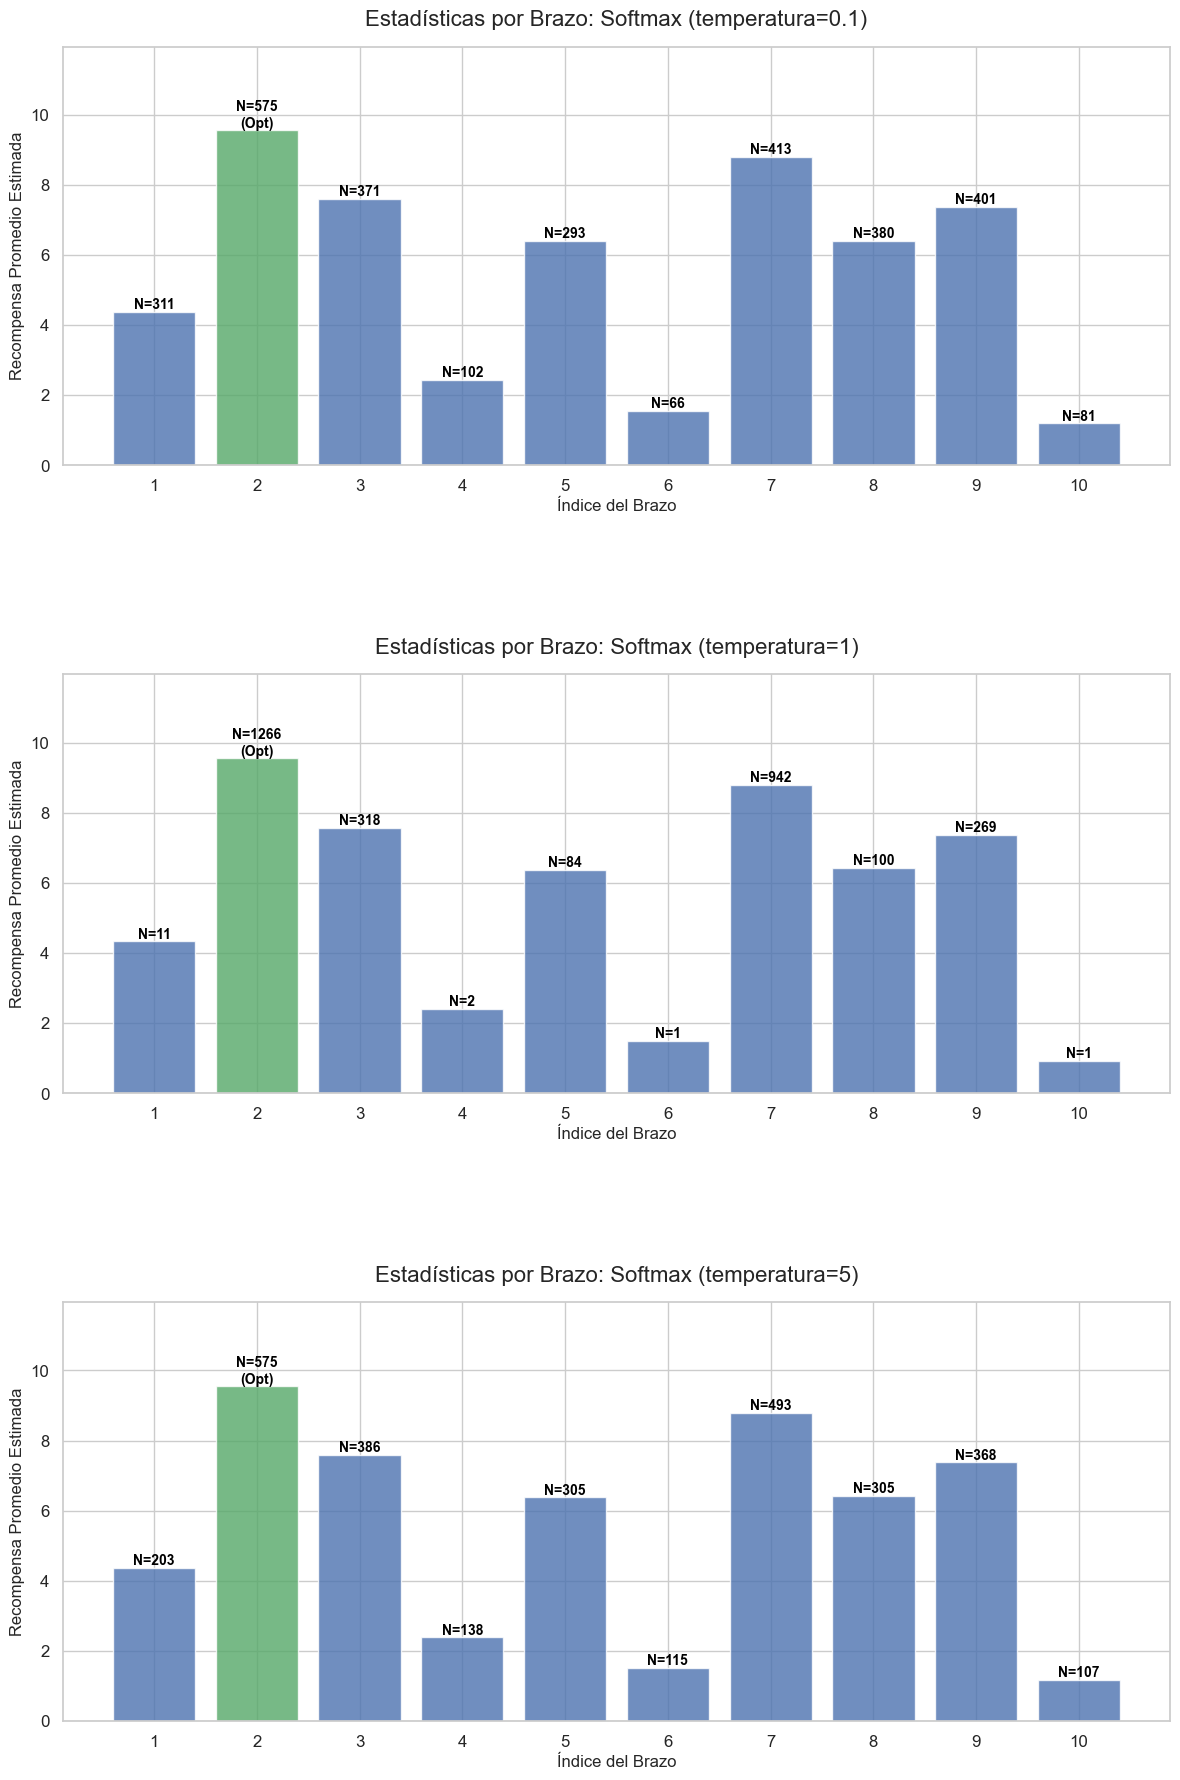

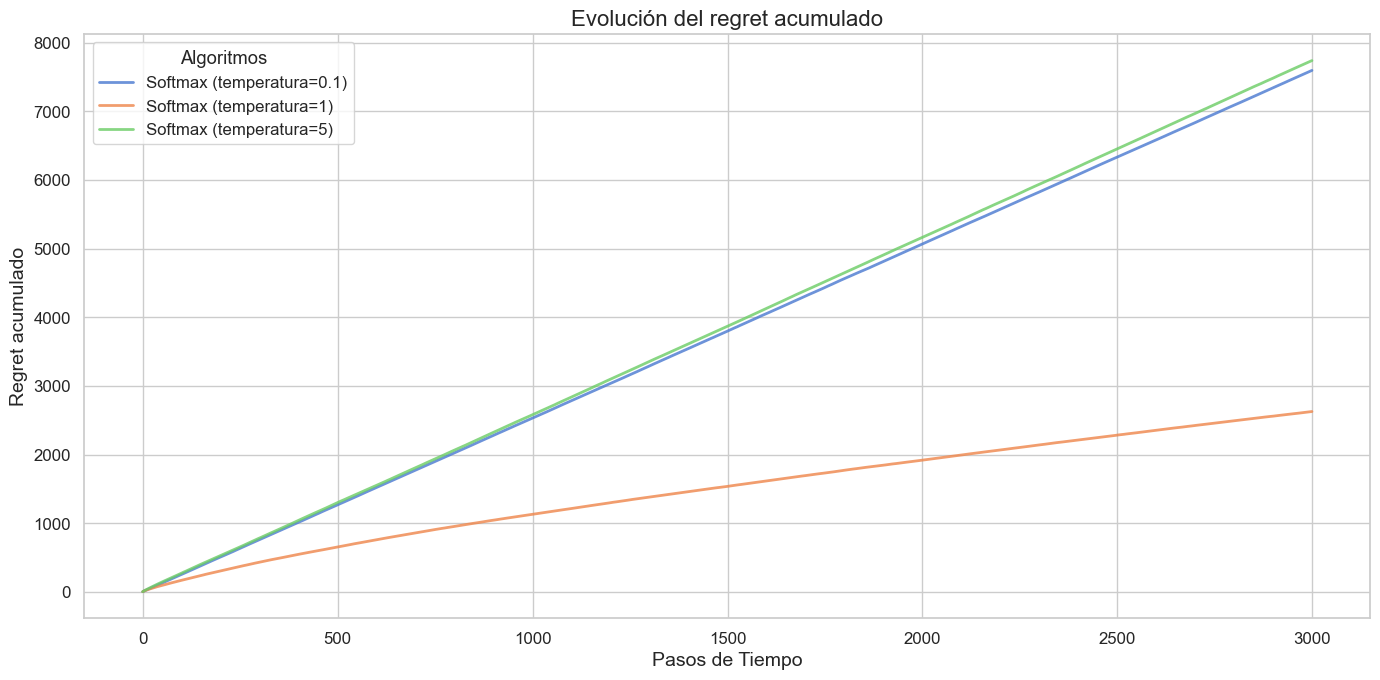

In [15]:
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

Los resultados obtenidos son muy similares a los del experimento anterior. Como sabemos, la distribución Bernoulli es más ruidosa que la normal, pues esta únicamente devuelve 0 o 1 (en nuestro caso, 0 o 10 tras el escalado), lo que hace que el algoritmo tenga más dificultades para distinguir entre los brazos. Sin embargo, el comportamiento general de los algoritmos softmax con diferentes temperaturas sigue siendo el mismo, con $\tau = 0.1$ quedándose atrapado en un óptimo local, $\tau = 1.0$ mostrando un equilibrio entre exploración y explotación, y $\tau = 0.1$ siendo demasiado explorador. 

Sin embargo, parece que el porcentaje de selección del brazo óptimo para $\tau = 1.0$ es algo mayor que en el experimento anterior (50% vs 45%), al igual que la recompensa promedio.

Además, en este caso la diferencia entre los algoritmos con $\tau = 5.0$ y $\tau = 0.1$ es mínima. Esto se debe a que la naturaleza extrema de la distribución de Bernoulli favorece al algoritmo con $\tau = 1.0$. Por ejemplo, si en primera instancia el algoritmo selecciona un brazo que estaba lejos de ser el óptimo, con la distribución normal veíamos que aún así el algoritmo se quedaba atrapado en ese brazo. Sin embargo, con la distribución Bernoulli, este brazo va a recibir muchas recompensas de 0, lo que hará que la probabilidad de selección de ese brazo disminuya rápidamente, lo que a su vez aumenta la probabilidad de que el algoritmo explore otros brazos.

### Experimento 3: Distribución binomial
Finalmente, realizamos el mismo experimento pero con brazos de distribución binomial, cada uno representando el número de éxitos en 10 pruebas con una probabilidad de éxito aleatoria entre 0.1 y 1.

In [16]:

np.random.seed(seed)  # Fijar la semilla para reproducibilidad

# Creación del bandit
bandit = Bandit(arms=ArmBinomial.generate_arms(k, n=10)) # Generar un bandido con k brazos de distribución binomial
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos softmax con diferentes valores de temperatura.
algorithms = [Softmax(k=k, temperature=0.1), Softmax(k=k, temperature=1), Softmax(k=k, temperature=5)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmBinomial(n=10, p=0.44, scale=1.0), ArmBinomial(n=10, p=0.96, scale=1.0), ArmBinomial(n=10, p=0.76, scale=1.0), ArmBinomial(n=10, p=0.24, scale=1.0), ArmBinomial(n=10, p=0.64, scale=1.0), ArmBinomial(n=10, p=0.15, scale=1.0), ArmBinomial(n=10, p=0.88, scale=1.0), ArmBinomial(n=10, p=0.64, scale=1.0), ArmBinomial(n=10, p=0.74, scale=1.0), ArmBinomial(n=10, p=0.12, scale=1.0)
Optimal arm: 2 with expected reward=9.556000000000001


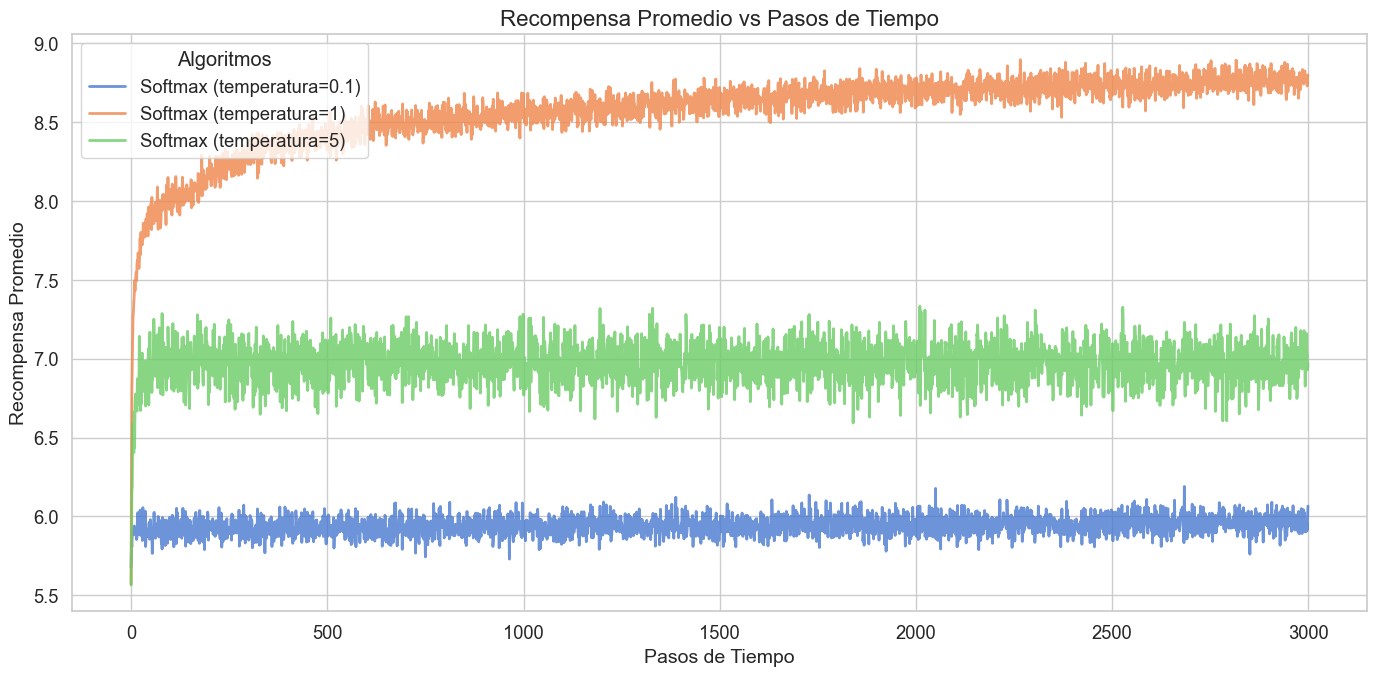

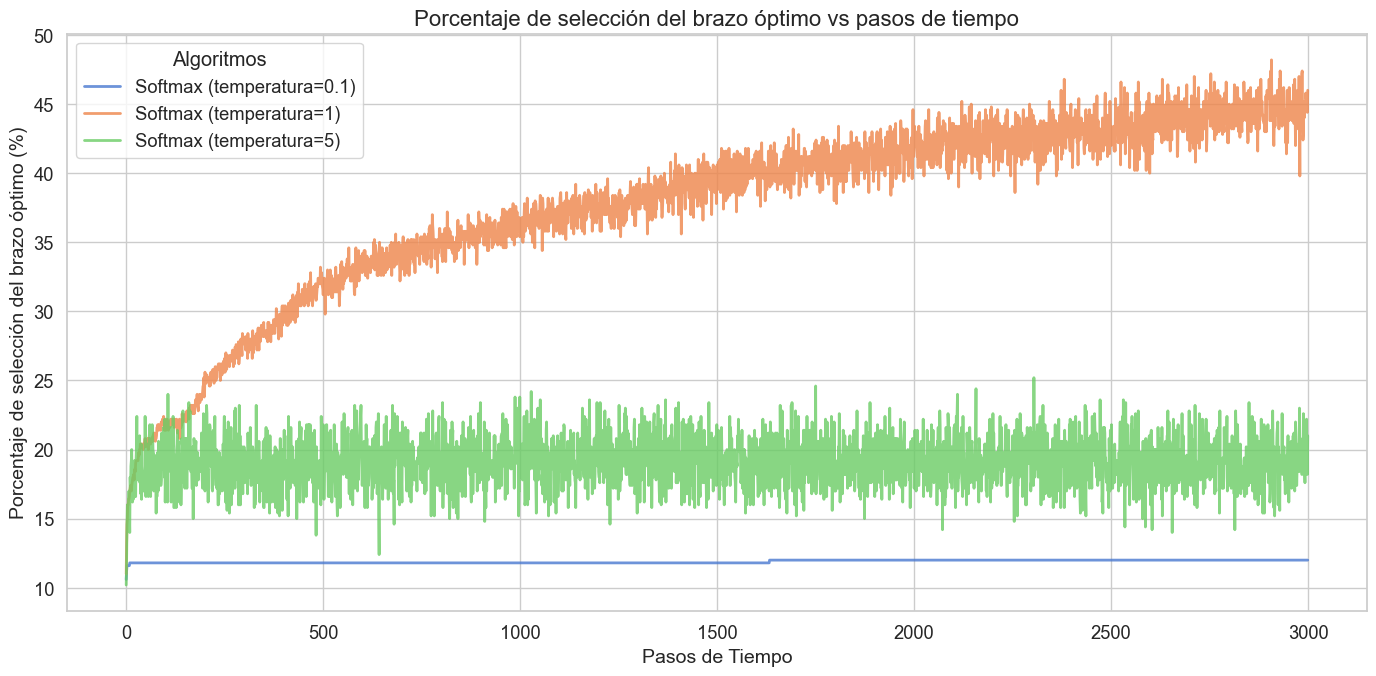

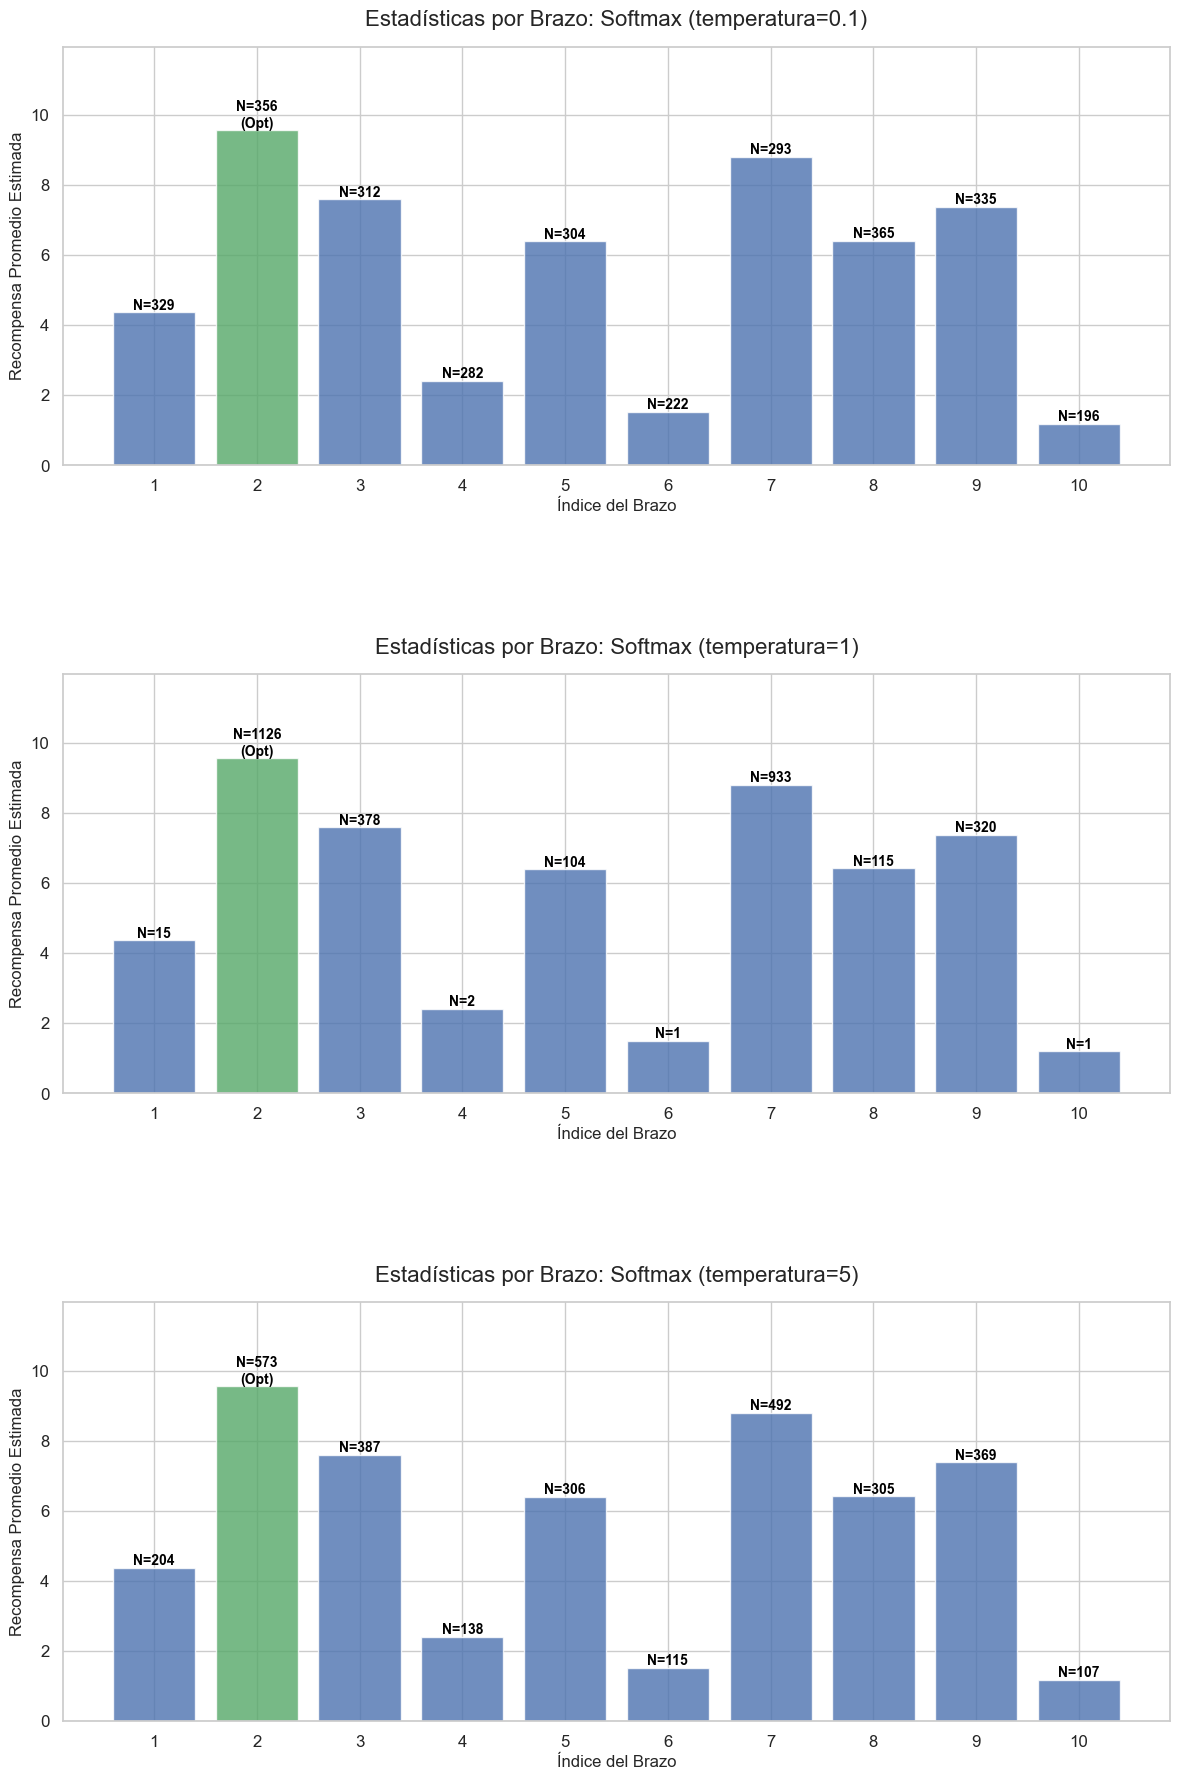

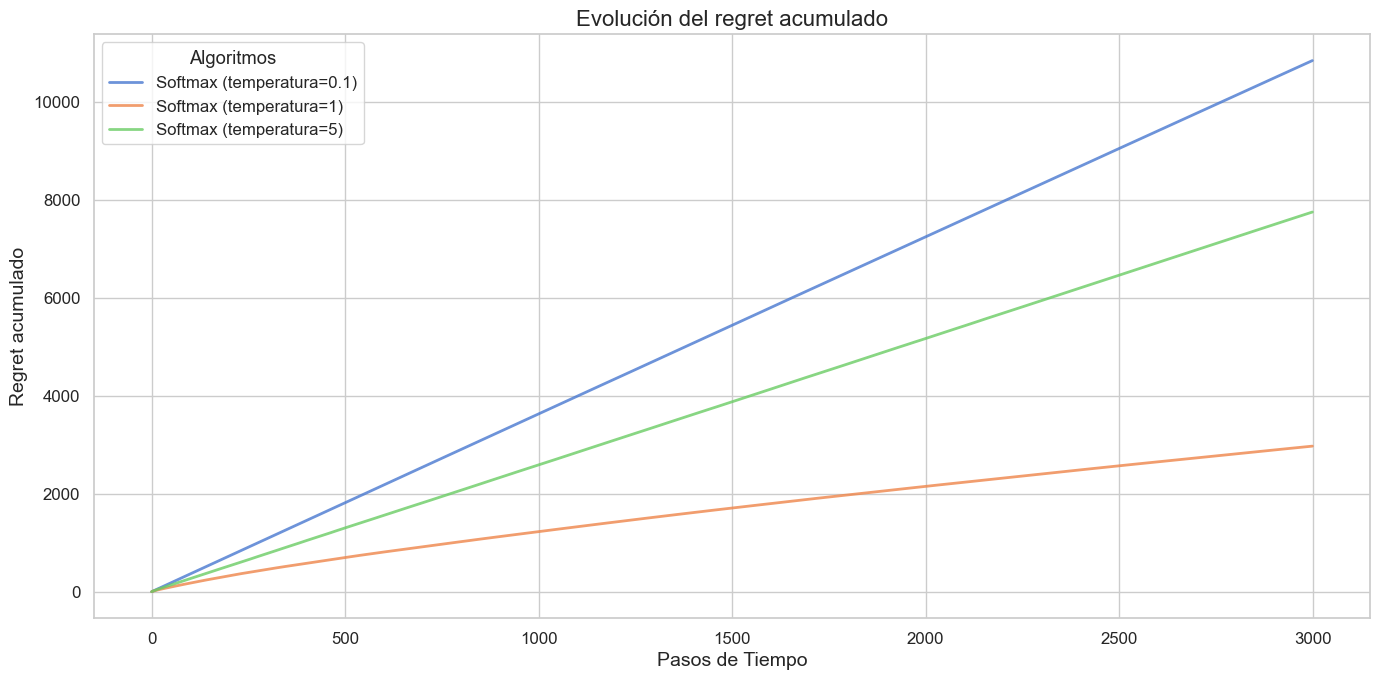

In [17]:
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

Obtenemos resultados pŕacticamente idénticos a los del experimento con distribución normal. Al realizar 10 experimentos de Bernoulli, el resultado se asemeja mucho a una distribución normal, de ahí que no haya mucha ninguna diferencia entre los resultados de ambos experimentos.


### Extra: Exploración Inicial para $\tau = 0.1$
En este experimento, nos centramos en el algoritmo softmax con $\tau = 1.0$, que es el más explotador de los tres. Dado que este algoritmo se queda atrapado en un óptimo local, queremos comprobar si realizar una exploración inicial por todos los brazos podría ayudar a mejorar su rendimiento. Para ello, realizamos una exploración inicial de 10 pasos, en los que el algoritmo selecciona cada uno de los brazos una vez, antes de comenzar a aplicar el algoritmo softmax con $\tau = 0.1$ durante el resto de los pasos.

Lo realizaremos para el caso de distribución normal, aunque se podrían realizar también para los otros tipos de distribución. Además, lo aplicaremos también para $\tau = 1.0$ y $\tau = 5.0$, aunque en estos casos no esperamos que la exploración inicial tenga un impacto tan significativo, dado que estos algoritmos ya muestran una mayor capacidad de exploración por sí mismos.

In [18]:
np.random.seed(seed)  # Fijar la semilla para reproducibilidad
# Creación del bandit
bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
print(bandit)

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definir los algoritmos a comparar. En este caso son 3 algoritmos epsilon-greedy con diferentes valores de epsilon.
algorithms = [Softmax(k=k, temperature=0.1, exploring=True), Softmax(k=k, temperature=1, exploring=True), Softmax(k=k, temperature=5, exploring=True)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections, arms_stats, regret_accumulated = run_experiment(bandit, algorithms, steps, runs)


Bandit with 10 arms: ArmNormal(mu=1.52, sigma=1.0), ArmNormal(mu=2.4, sigma=1.0), ArmNormal(mu=1.19, sigma=1.0), ArmNormal(mu=4.37, sigma=1.0), ArmNormal(mu=6.39, sigma=1.0), ArmNormal(mu=7.59, sigma=1.0), ArmNormal(mu=8.8, sigma=1.0), ArmNormal(mu=9.56, sigma=1.0), ArmNormal(mu=6.41, sigma=1.0), ArmNormal(mu=7.37, sigma=1.0)
Optimal arm: 8 with expected reward=9.56


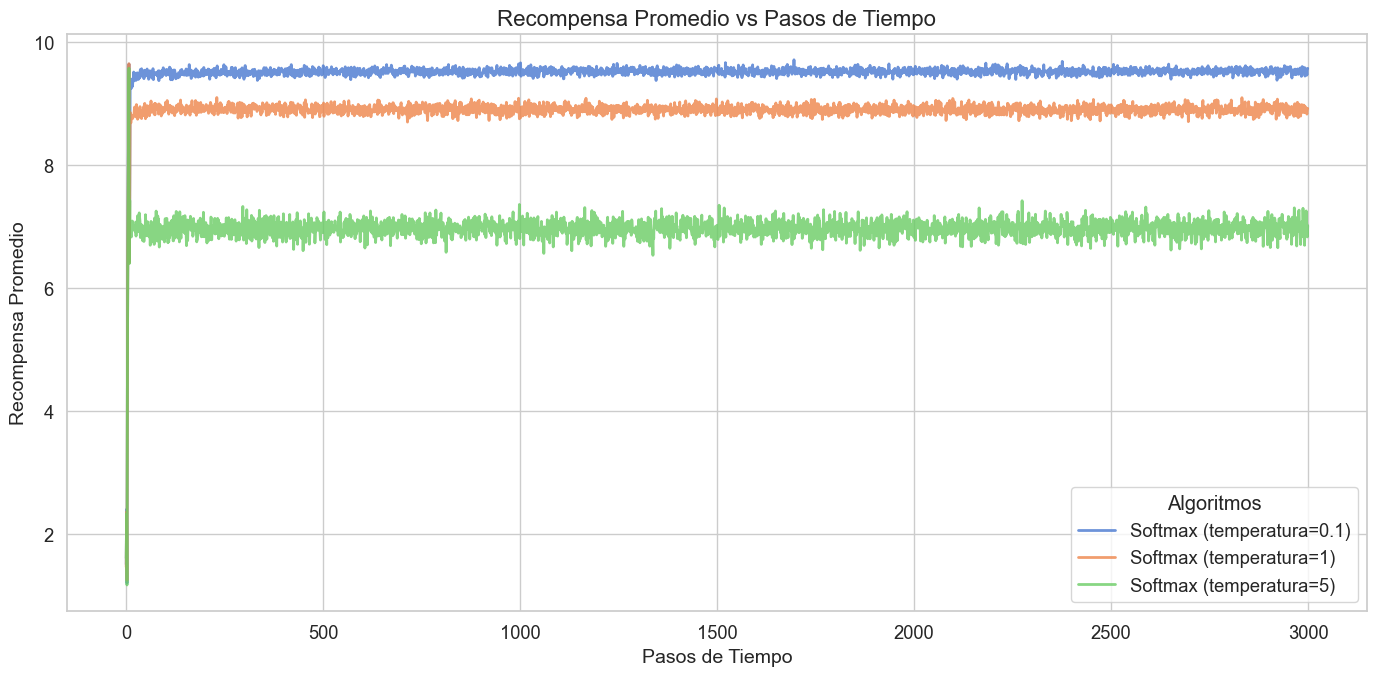

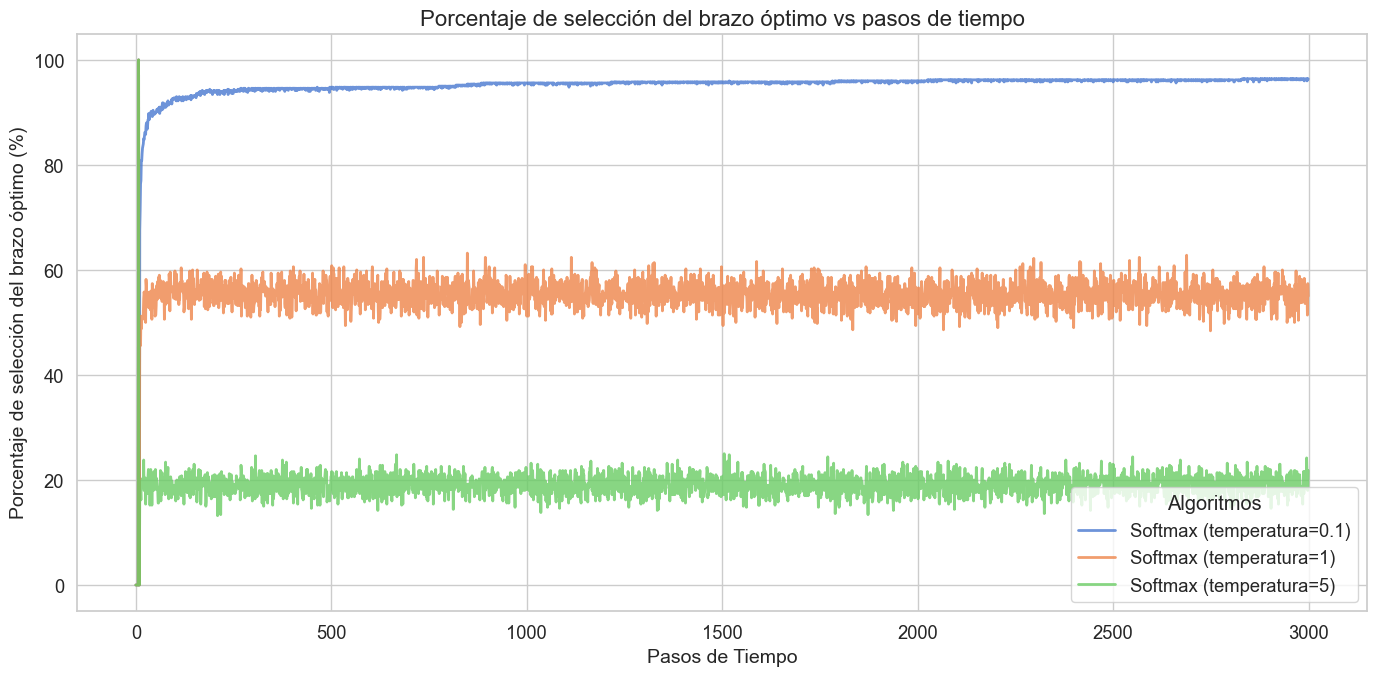

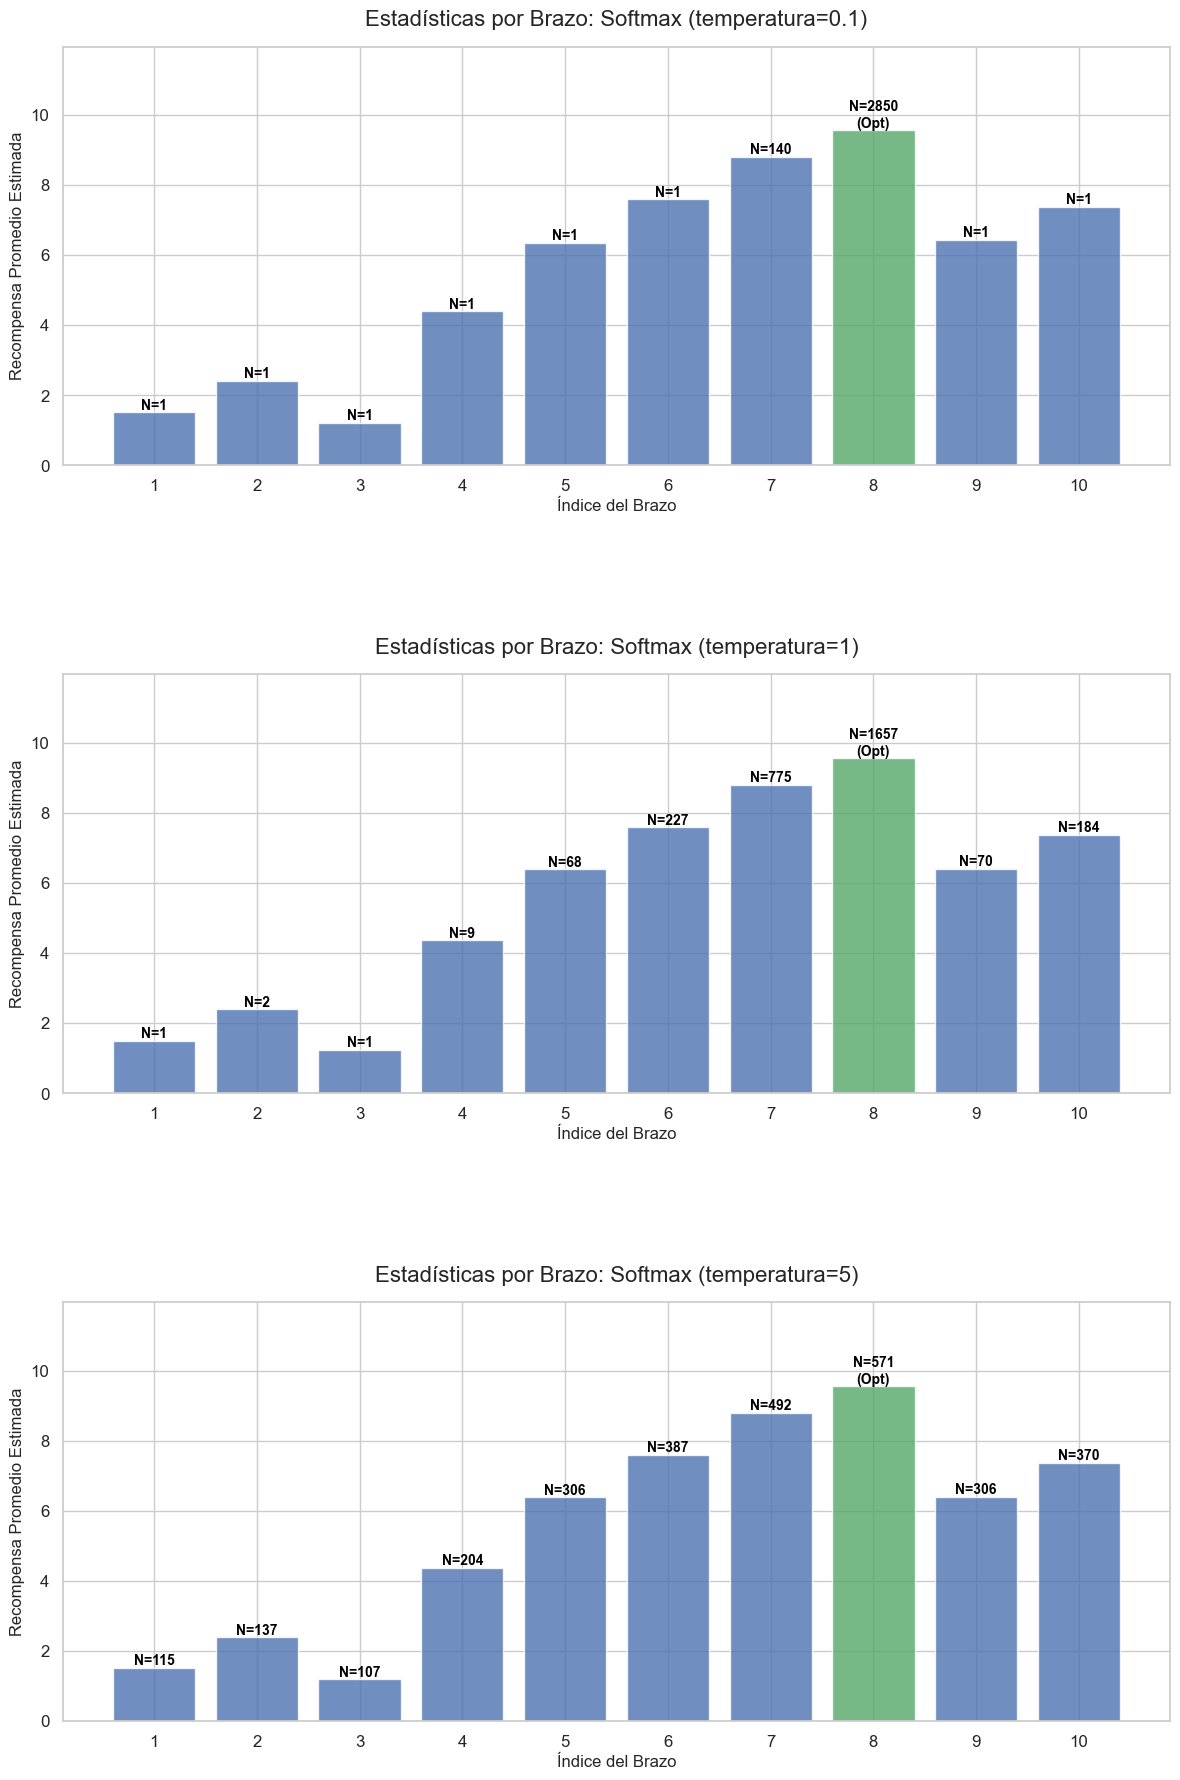

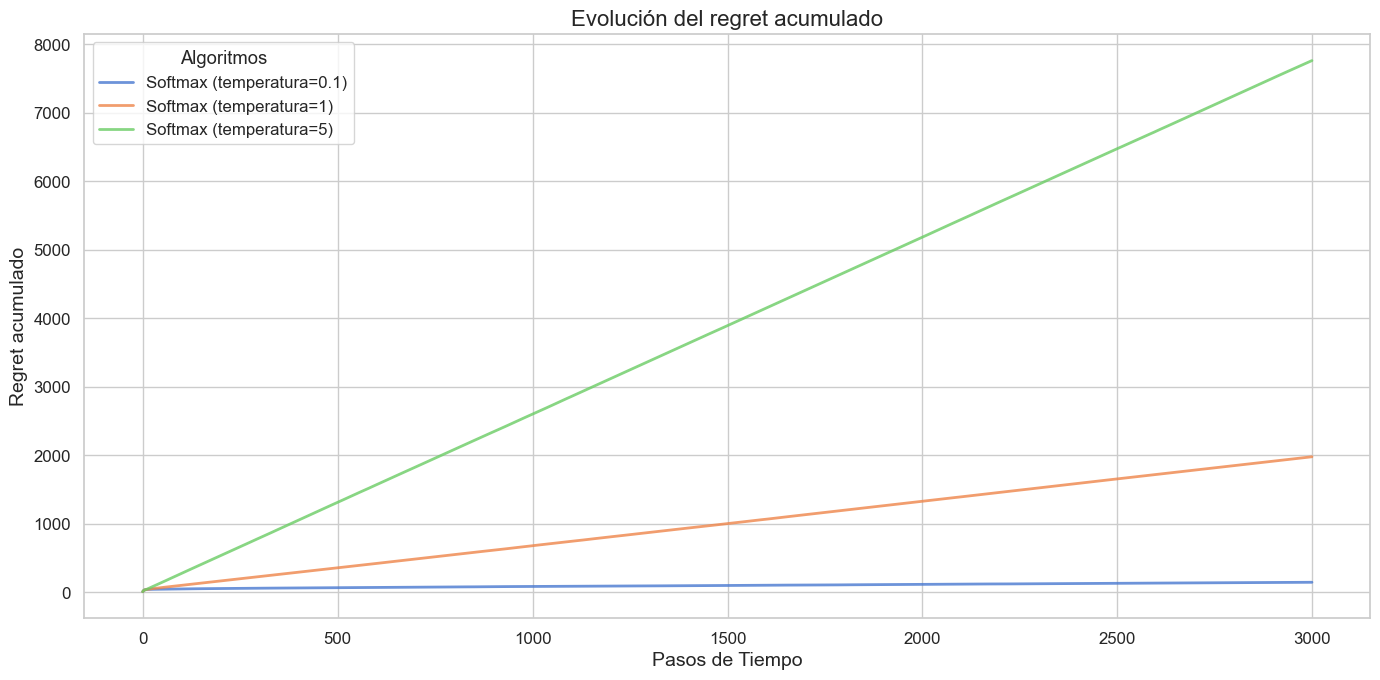

In [19]:
plot_average_rewards(steps, rewards, algorithms)
plot_optimal_selections(steps, optimal_selections, algorithms)
plot_arm_statistics(arms_stats, algorithms, optimal_arm)
plot_regret(steps, regret_accumulated, algorithms)

Los resultados obtenidos son justo lo que esperábamos. Para el caso de $\tau = 0.1$, la exploración inicial permite al algoritmo descubrir el brazo óptimo desde el principio, lo que hace que la recompensa promedio y el porcentaje de selección del brazo óptimo sean los más altos acercándose al óptimo. Sin embargo, para los casos de $\tau = 1.0$ y $\tau = 0.1$, la exploración inicial no tiene un impacto significativo en el rendimiento del algoritmo, siendo ligeramente mejor para $\tau = 1.0$ y completamente irrelevante para $\tau = 5.0$.

También cabe destacar que sin la exploración inicial, los algoritmos tardaban alrededor de 3000 steps en estabilizarse, mientras que con la exploración inicial, el algoritmo con $\tau = 0.1$ se estabiliza mucho antes, alrededor de los 500 steps.

# Conclusiones
Tras analizar el comportamiento del algoritmo Softmax bajo diferentes configuraciones de temperatura (τ) y distintas distribuciones de probabilidad (Normal, Bernoulli y Binomial), podemos concluir lo siguiente:

### El impacto crítico del parámetro de temperatura ($\tau$) 
Este parámetro define por completo el equilibrio entre exploración y explotación en el algoritmo Softmax, y su elección hemos visto que tiene un impacto crítico en el rendimiento del agente:

- Temperaturas bajas ($\tau$=0.1): Inducen un comportamiento casi voraz (greedy). Aunque permiten aprovechar rápidamente las recompensas altas, presentan un alto riesgo de convergencia prematura hacia óptimos locales, ignorando el brazo verdaderamente óptimo si no se descubre pronto.

-  Temperaturas intermedias ($\tau$=1.0): Ofrecen el equilibrio más robusto y consistente. Permiten una exploración ponderada y proporcional al valor estimado de cada brazo, de manera que se logra un rendimiento cercano al óptimo a largo plazo.

- Temperaturas altas ($\tau$=5.0): Suavizan en exceso las diferencias entre los valores Q estimados, forzando al agente a comportarse de manera casi puramente aleatoria.

### Sensibilidad a la naturaleza de la distribución

Hemos observado que el rendimiento de las distintas temperaturas no es universal, sino que depende fuertemente de la distribución de las recompensas:

- Entornos Continuos (Normal): El algoritmo se comporta exactamente según lo esperado teóricamente. τ=1.0 domina claramente, mientras que τ=0.1 fracasa al quedarse atascado en brazos subóptimos.
  
- Entornos Discretos/Extremos (Bernoulli y Binomial): Observamos un fenómeno de "autocorrección" para τ=0.1. Debido a que las recompensas en Bernoulli son extremas (0 o 10), un solo fracaso desploma el valor estimado del brazo. Esto obliga al algoritmo voraz a cambiar de opción rápidamente, logrando un rendimiento superior al caso de la distribución normal.

### La eficacia de la exploración inicial forzada

El experimento adicional demuestra que la principal debilidad de las temperaturas bajas (el estancamiento en óptimos locales) puede mitigarse drásticamente la exploración inicial forzada, que consiste en probar cada brazo una vez antes de aplicar la política Softmax.

Esta modificación hace que $\tau=0.1$ sea la estrategia ganadora, pues logra las recompensas promedio más altas y acelera la estabilización del sistema de forma notable (convergiendo en apenas 500 pasos frente a los 3000 originales).

Por el contrario, confirmamos que esta técnica es redundante e innecesaria para temperaturas τ≥1.0, ya que estas ya presentan una exploración natural suficiente.